In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from photutils import aperture as ap
import scipy as sp
import glob

In [2]:
# first, import expected target locations from imdat

header = fits.open('reduced_images/2m0753.0001.fits')[0].header
print(header)

image_data = open('imdat3.2m0753', 'r')
line_list = []
for line in image_data:
    line_list.append(line.strip().split())
#print(line_list)
image_data.close()

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 1365                                                  NAXIS2  =                 1172                                                  ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        DATE    = '2026-03-05T02:12:10' / Date FITS file was generated                  IRAF-TLM= '2026-03-26T03:34:50' / Time of last modification                     OBJECT  = '2M0753+2324'        / Name of the object observed                    CCDSUM  = '3 3     '           / CCD pixel summing                              CCDBIN1 =                    3 / Binning factor along axis 1                    CCDBIN2 =                    3 / Binning factor along axis 2                    FILENAME= 'TempImage2402.fits' / base fi

In [3]:
stars_list = np.array(line_list[7:18], dtype=np.float64) # clip the imdat to just the stars we're interested in photometrically
# sdB is star number 5

# I would like to be able to use RA/DEC for per-image position correction, but unfortunately (like DS9), I cannot identify a supported mapping
# from image file to WCS in the header for our data images. The unit typing of each axis *seems* to imply that they are rectified and aligned with
# ra/dec, but I would really prefer to have any sort of standard CD matrix to justify that assumption, and I can accomplish what I need without it
# (I think), it's just more annoying.

In [4]:
# we're going to do dynamic fitting because I'm crazyyy
def SNR (image, x_pos, y_pos, r): # we need this for the scipy optimize call
    aper = ap.CircularAperture((x_pos, y_pos), r) # no dark current... odd. I won't give the signal or noise non-poisson error I suppose, this is all
    ann = ap.CircularAnnulus((x_pos, y_pos), 4/2.25*r, 6/2.25*r) # internal work anyways
    sum_ap, err_ap = aper.do_photometry(image, error=np.sqrt(np.abs(image)))
    sum_an, err_an = ann.do_photometry(image, error=np.sqrt(np.abs(image)))
    SNR = sum_ap[0]/(sum_an[0] * aper.area/ann.area) # sum of signal over expected sum of noise in area. Eq. to mean(annulus)
    
    # propagate poisson - func = c * ap * (an)^-1 -> df = c*(dap*an^-1 - ap*dan*an^-2) -> err^2 = c^2 * (err_ap^2 * an^-2 - ap^2 * err_an^2 * an^-4)
    c = ann.area/aper.area
    SNR_err = np.sqrt(c**2 * ((err_ap[0]/sum_ap[0])**2 + (sum_ap[0]*err_an[0]/(sum_an[0]**2))**2)) # just propagated poisson right now
    return SNR, SNR_err # we can't return the SNR_err for scipy curve_fit
    
# scipy needs a function to minimize, not maximize. Among other things, I want a separate function for it
def scipy_packer (params, image):
    x_pos, y_pos, r = params # r is the aperture radius in pixels
    SNR_val, SNR_err = SNR(image, x_pos, y_pos, r)
    return 1/SNR_val # should optimize fairly well

In [11]:
files_list = glob.glob('reduced_images/*.fits')
HJD_arr, fluxes_arr = [], []
j = 0 # just for some feedback about how fast it's going

for file in files_list:
    hdul = fits.open(file)
    image = hdul[0].data
    header = hdul[0].header # we can get some important info from this
    
    HJD = header['HJD'] # our time coordinate, some sort of super centered julian date
    HJD_arr.append(HJD)
    fluxes = [] # array to hold the fluxes of each star

    # we have a good guess for the position of each star over time in stars_list, but we would like to optimize for aperture and annulus SNR for each
    # star for each image. There's only 800 images, 11 stars, shouldn't be too bad
    # I happen to know that the typical displacement from aligned for each image was < 0.5 arcsec in either direction. At a pixel scale of 0.15 arcsec
    # /pix, a range of 10 pixels should be more than enough to optimize. We have from Dr. Green the recommendation of aperture radius 2.25xfwhm - .stats
    # file gives us fwhms, we could either read in that file or let the aperture radius vary from fwhm of 3 to 5 + flex room.
    # we also have to stay under 18 pixels to avoid contamination from nearby neighbors. We could take sky values from an annulus, or from the dark sky
    # patches that our data file outlines - Dr. Green recommends the latter due to sky variance, which I can accept despite being lazy. Again from Dr.
    # Green, a decent sky region is 4xfwhm out to +2xfwhm (4x star aperture area. Technically sqrt(165)/2 - 4 but who's counting). I don't want to vary
    # the sky annulus because I'm worried that dynamically modifying the error region will create perverse incentives. Also, I am just a *little* worried
    # about processing time.
    for i in range(np.shape(stars_list)[0]):
        x_pos, y_pos = stars_list[i,1], stars_list[i,2]
        guess = np.array([x_pos, y_pos, 9]) # assume FWHM ~ 4
        out = sp.optimize.minimize(scipy_packer, guess, args=image, bounds=[(x_pos-5, x_pos+5),(y_pos-5, y_pos+5),(6, 12)])
        x_pos_opt, y_pos_opt, r_opt = out.x # it's incredible how quick these operations are. Just for me to remember if I ever get frustrated with them
        opt_ap = ap.CircularAperture((x_pos_opt, y_pos_opt), r_opt)
        opt_an = ap.CircularAnnulus((x_pos_opt, y_pos_opt), 4/2.25*r_opt, 6/2.25*r_opt)
        flux, poisson_err = opt_ap.do_photometry(image, error=np.sqrt(image))
        sky_err, err_sky_err = np.array(opt_an.do_photometry(image, error=np.sqrt(image)))*opt_ap.area/opt_an.area # multiplication by constant, ~1/4
        tot_phot_err = poisson_err + sky_err + err_sky_err # total photometric error - sky_err > [2oM] poisson_err > err_sky_err [1oM]
        fluxes.append([flux, tot_phot_err])

    fluxes_arr.append(fluxes)
    
    if j%10 == 0:
        print(j)
    j += 1
    
    hdul.close()

fluxes_arr = np.array(fluxes_arr)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780
790
800


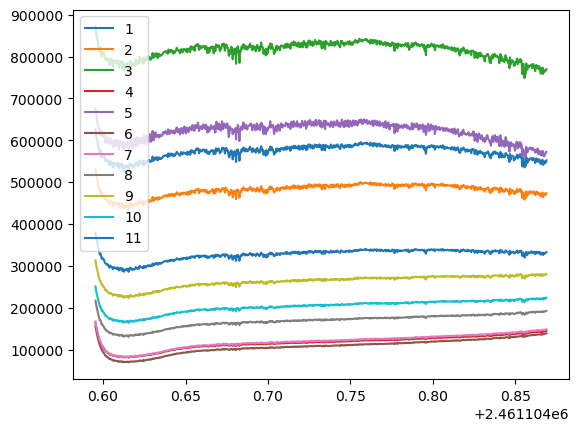

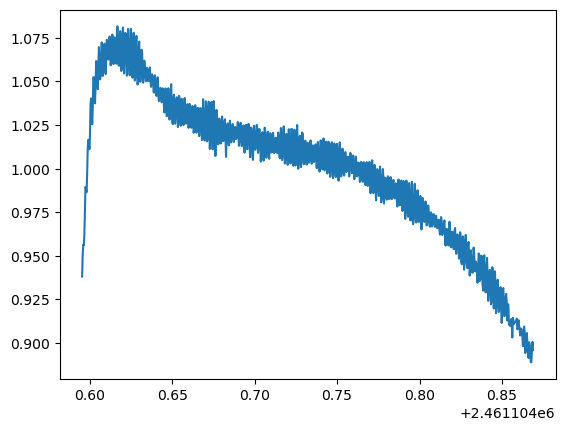

In [20]:
plt.figure()
plt.plot(HJD_arr, fluxes_arr[:,:,0,0], label=['1','2','3','4','5','6','7','8','9','10','11'])
plt.legend()

plt.figure()
target_star = fluxes_arr[:,4,0,0]
phot_corr = np.mean([fluxes_arr[:,0,0,0],fluxes_arr[:,1,0,0],fluxes_arr[:,2,0,0],fluxes_arr[:,3,0,0],fluxes_arr[:,5,0,0],fluxes_arr[:,6,0,0],
                    fluxes_arr[:,7,0,0],fluxes_arr[:,8,0,0],fluxes_arr[:,9,0,0],fluxes_arr[:,10,0,0]], axis=0)
corr_target = target_star/phot_corr
plt.plot(HJD_arr, corr_target/np.mean(corr_target))

In [25]:
# should probably do out with pandas, but save the numpy arrays just to be sure
np.save('fluxes', fluxes_arr[:,:,:,0])
np.save('HJD', HJD_arr)